In [65]:
import ast
import itertools
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

In [66]:
df = pd.read_csv("clip_quality.csv")

In [67]:
positive_prompts = [
"a high quality image",
"a detailed coherent image",
"a visually pleasing image",
"a clear image",
"a sharp natural image",
]

negative_prompts = [
"a low quality distorted image",
"an unrealistic malformed image",
"a blurry incoherent image",
"an image with visible artifacts",
]

In [68]:
#convert the strings in the positive_scores_list and negative_scores_list columns from strings to lists
def parse_list_col(x):

    if isinstance(x, str):
        return ast.literal_eval(x)
    return x


df["positive_scores_list"] = df["positive_scores_list"].apply(parse_list_col)
df["negative_scores_list"] = df["negative_scores_list"].apply(parse_list_col)


In [69]:
pos_matrix = np.vstack(df["positive_scores_list"].to_numpy())
neg_matrix = np.vstack(df["negative_scores_list"].to_numpy())
labels = df["label"].astype(float).to_numpy()

In [70]:
def compute_subset_score(
    pos_matrix: np.ndarray,
    neg_matrix: np.ndarray,
    pos_idx: list[int],
    neg_idx: list[int],
) -> np.ndarray:
    """
    Compute image quality score from selected positive and negative prompts.

    Score = mean(selected positive prompt scores)
            - mean(selected negative prompt scores)

    If no negative prompts are selected, score = mean(selected positive prompts).
    """
    pos_score = pos_matrix[:, pos_idx].mean(axis=1)

    if len(neg_idx) > 0:
        neg_score = neg_matrix[:, neg_idx].mean(axis=1)
        return pos_score - neg_score

    return pos_score



In [71]:
# Score all prompt combinations and compute Spearman correlation with human-annotated labels
def search_best_prompt_combinations(
    pos_matrix: np.ndarray,
    neg_matrix: np.ndarray,
    labels: np.ndarray,
) -> pd.DataFrame:
    """
    Brute-force all positive/negative prompt subsets.

    Requires at least one positive prompt.
    Allows zero or more negative prompts.
    """
    results = []

    P = pos_matrix.shape[1]
    Q = neg_matrix.shape[1]

    for k_pos in range(1, P + 1):
        for pos_idx in itertools.combinations(range(P), k_pos):

            for k_neg in range(0, Q + 1):
                for neg_idx in itertools.combinations(range(Q), k_neg):

                    scores = compute_subset_score(
                        pos_matrix=pos_matrix,
                        neg_matrix=neg_matrix,
                        pos_idx=list(pos_idx),
                        neg_idx=list(neg_idx),
                    )

                    corr, p_value = spearmanr(scores, labels)

                    results.append({
                        "pos_idx": pos_idx,
                        "neg_idx": neg_idx,
                        "num_pos": len(pos_idx),
                        "num_neg": len(neg_idx),
                        "spearman": corr,
                        "p_value": p_value,
                    })

    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values("spearman", ascending=False)

    return results_df


results_df = search_best_prompt_combinations(
    pos_matrix=pos_matrix,
    neg_matrix=neg_matrix,
    labels=labels,
)

In [72]:
# Inspect best result
best = results_df.iloc[0]

print("Best Spearman:", best["spearman"])
print("p-value:", best["p_value"])
print("Positive prompt indices:", best["pos_idx"])
print("Negative prompt indices:", best["neg_idx"])

print("\nBest positive prompts:")
for i in best["pos_idx"]:
    print("-", positive_prompts[i])

print("\nBest negative prompts:")
for i in best["neg_idx"]:
    print("-", negative_prompts[i])


results_df.to_csv("prompt_subset_spearman_results.csv", index=False)


Best Spearman: 0.8633347996322558
p-value: 2.27279285840084e-17
Positive prompt indices: (0, 2, 3, 4)
Negative prompt indices: (1, 2, 3)

Best positive prompts:
- a high quality image
- a visually pleasing image
- a clear image
- a sharp natural image

Best negative prompts:
- an unrealistic malformed image
- a blurry incoherent image
- an image with visible artifacts


In [75]:
#Append best score back to df
best_pos_idx = list(best["pos_idx"])
best_neg_idx = list(best["neg_idx"])

df["best_prompt_score"] = compute_subset_score(
    pos_matrix=pos_matrix,
    neg_matrix=neg_matrix,
    pos_idx=best_pos_idx,
    neg_idx=best_neg_idx,
)

#df.to_csv("clip_results_with_best_prompt_score.csv", index=False)

# Visualization of Results


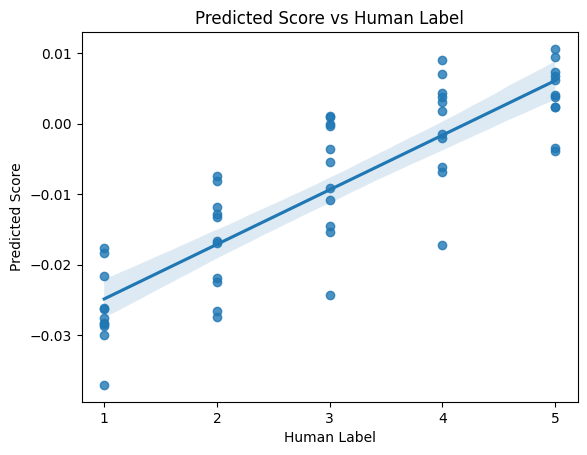

In [78]:
sns.regplot(x=df["label"], y=df["best_prompt_score"])
plt.title("Predicted Score vs Human Label")
plt.xlabel("Human Label")
plt.ylabel("Predicted Score")

plt.xticks([1, 2, 3, 4, 5])
plt.show()

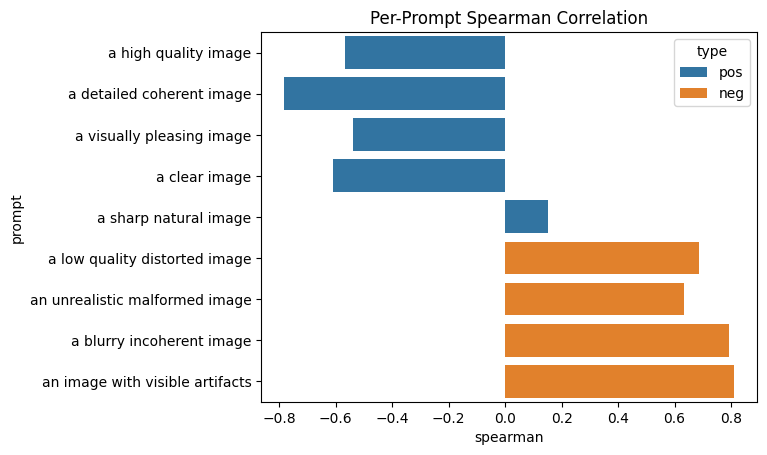

In [79]:
prompt_corrs = []

for i, p in enumerate(positive_prompts):
    corr = spearmanr(pos_matrix[:, i], labels)[0]
    prompt_corrs.append(("pos", p, corr))

for i, p in enumerate(negative_prompts):
    corr = spearmanr(-neg_matrix[:, i], labels)[0]
    prompt_corrs.append(("neg", p, corr))  # flip sign

corr_df = pd.DataFrame(prompt_corrs, columns=["type", "prompt", "spearman"])

sns.barplot(data=corr_df, x="spearman", y="prompt", hue="type")
plt.title("Per-Prompt Spearman Correlation")
plt.show()